In [ ]:
#This notebook generates the Nguyen figures that comprise Figure 2 in the paper

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyrenn
sns.set(style='ticks')
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.interpolate import griddata
from scipy.stats import spearmanr
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from pickle import load
import matplotlib.gridspec as gridspec
import ast
import sys
BMS_path='../bin/'
sys.path.append(BMS_path + 'no_degeneracy/')
sys.path.append(BMS_path + 'no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par
import math

from functions.plot_style import set_plot_style, colors_figures, text_size

In [2]:
#A function to return mdl models from traces
#------------------------------------------------------
def get_mdl(df_var, trace_var,two_dimensions=False ):

    
     #Two-dimensional (only nguyen n=10) or one-dimensional functions
    if two_dimensions==True:
         VARS = ['x','y',]
         prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv2.np10.2016-09-09 18:49:42.600380.dat')
    else:
        VARS = ['x',]
        prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')

    #Discriminate ann-generated vs nugyen functions
    #-----------------------------------------------
    try:
        x = df_var[[c for c in VARS]].copy()
        y=df_var.z_noise   
    except KeyError:
        VARS = ['x1',]
        x = df_var[[c for c in VARS]].copy()
        y=df_var.y_noise
    #-----------------------------------------------
    
    minrow = trace_var[trace_var.H == min(trace_var.H)].iloc[0]
    minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)
    
    tvar= Tree(
        variables=list(x.columns),
        parameters=['a%d' % i for i in range(NPAR)],
        x=x, y=y,
        prior_par=prior_par,
        max_size=200,
        from_string=minexpr,
    )

    tvar.set_par_values(deepcopy(minparvals))
    x_var=x;y_var=y
    
    return tvar, x_var, y_var
#------------------------------------------------------

#Errors single plot
#--------------------------------------------------------------------------
def compute_errors_single_plot(df_function):
    
    #Validation and train borders
    n_points=int(len(df_function.index))
    
    train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
    train_size_ann=int(n_points*train_fraction)
    train_size_bms=train_size_ann + int(n_points*valid_fraction)
    train_border=df_function.loc[train_size_bms-1]['x']

    #compute errors
    #ann errors
    rmse_nn_tr=root_mean_squared_error(df_function.loc[:train_size_bms-1]['zmodel'],df_function.loc[:train_size_bms -1]['z'])
    rmse_nn_tt=root_mean_squared_error(df_function.loc[train_size_bms-1:]['zmodel'],df_function.loc[train_size_bms -1:]['z'])

    #bms errors
    try:
        rmse_mdl_tr=root_mean_squared_error(dplot.loc[:train_size_bms-1]['zbms'],dplot.loc[:train_size_bms-1]['z'])
    except ValueError:
        rmse_mdl_tr=np.inf
    try:
        rmse_mdl_tt =root_mean_squared_error(dplot.loc[train_size_bms-1:]['zbms'],dplot.loc[train_size_bms-1:]['z'])
    except ValueError:
        rmse_mdl_tet=np.inf


    return rmse_nn_tr, rmse_nn_tt, rmse_mdl_tr, rmse_mdl_tt, train_border
#--------------------------------------------------------------------------   

#Figure settings
#--------------------------------

#Paths, extensions, and figure size
#--------------------------------
output_path='../results/paper_figures/figure2_nguyen/'      
extensions=['.svg', '.png']    
#Define figure size in cm
cm = 1/2.54 #convert inch to cm
width = 16*cm; height=16*cm 
#--------------------------------

#Text sizes  
#--------------------------------
#size_axis=16;size_ticks=14;
#size_title=16;
line_w=3;marker_s=8;m_size=10
size_legend=14
#--------------------------------


#ticks and limits for nguyen functions
#--------------------------------
ticks={1:{'x':[0, 0.5, 1],'y':[ -3, 0, 3, 6.0]}, 5:{'x':[-1, 0, 1], 'y':[-0.75,-0.5, -0.25]}, 
       7:{'x':[0,1,2,],   'y': [1,2,3]}, 8:{'x':[0,2,4], 'y':[0, 1, 2]}, 
       10:{'x':[0,0.5,1], 'y':[0,0.5,1], 'z':[0,0.5,1] } }

limits={1:{'x':[-1.1,1.1], 'y':[-3.25, 8]}, 5:{'x':[-1.2,1.2], 'y':[-0.8,-0.2]}, 
        7:{'x':[-0.1,2.1], 'y': [0.4,3.1]}, 8:{'x':[-0.1,4.2], 'y':[-0.1, 2.5]}, 
        10:{'x':[-0.1,1.1], 'y':[-0.1,1.1], 'z':[-0.1,1.1] } } 

#x, y, vertical distance between two lines of text
coordinates_text={5:[-0.73, -0.3, 0.075], 7:[0.4, 0.75, 0.3], 8:[0.4, 0.3, 0.3], 10:[0.15, 0.15, 0.3, 0.3]}
loc_legend={5:'lower left', 7:'upper left', 8: 'upper left', 10: 'upper left'}
#--------------------------------

#nguyen title dict
#--------------------------------
titles={1: r'$y_1=3.39 x^3 + 2.12 x^2 +1.78x$',
        5: r'$y_5=\sin(x^2) \cos(x)$', 
        7: r'$y_7=\log(x+1.4) + \log(x^2 + 1.3)$',
        8: r'$y_8=\sqrt{1.23x}$',
        10:r'$y_{10}=\sin(1.5x) \cos(0.5y)$' }
#--------------------------------


#Approximations, interpolations, extrapolations
#--------------------------------
markers = {'rmse_nn_train': 'o', 'rmse_mdl_train': 's'}
xtick_labels=np.arange(0.0,0.22,0.04)

resamples=100000; bs_seed=1111
ymin=1e-17;ymax=10
#--------------------------------

In [3]:
#Read Nguyen data

NPAR=10 #10, 20
steps=50000

path_nguyen_nn= '../data/nns/nguyen/approximation/'

#Read nguyen data
#-------------------------------------------------------------------------------
functions_to_plot={5: {'sigma': 0.04, 'realization': 2}, 
                   7: {'sigma': 0.04,'realization': 0}, 
                   10:{'sigma': 0.02,'realization': 1} }

n=7
sigma=functions_to_plot[n]['sigma']
realization=functions_to_plot[n]['realization']


file_model_ng1= path_nguyen_nn + 'NN_no_overfit_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
dng1=pd.read_csv(file_model_ng1,index_col=0)
#-------------------------------------------------------------------------------

#Read nguyen trace
#-------------------------------------------------------------------------------
dng1=dng1[dng1['rep']==n]
dng1=dng1.reset_index(drop=True)
path_nguyen_bms='../data/MSTraces/nguyen/'
trace_ng=path_nguyen_bms + 'BMS_nguyen_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_trace_'+str(steps)+'_prior_10'+ '.csv'
trace=pd.read_csv(trace_ng, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])

if n!=10:
    t1,x1,y1=get_mdl(dng1, trace)
else:
    t1,x1,y1=get_mdl(dng1, trace, two_dimensions=True)
#-------------------------------------------------------------------------------


<lambdifygenerated-11>:2: RuntimeWarning: divide by zero encountered in power
  return x*x**_a1_ + x
<lambdifygenerated-11>:2: RuntimeWarning: invalid value encountered in multiply
  return x*x**_a1_ + x


(((x ** _a1_) * _a1_) + _a7_)

{'d0': {'_a1_': 1.1322810821345146,
  '_a7_': 0.5747194947570649,
  '_a0_': 1.0,
  '_a2_': 1.0,
  '_a3_': 1.0,
  '_a4_': 1.0,
  '_a5_': 1.0,
  '_a6_': 1.0}}

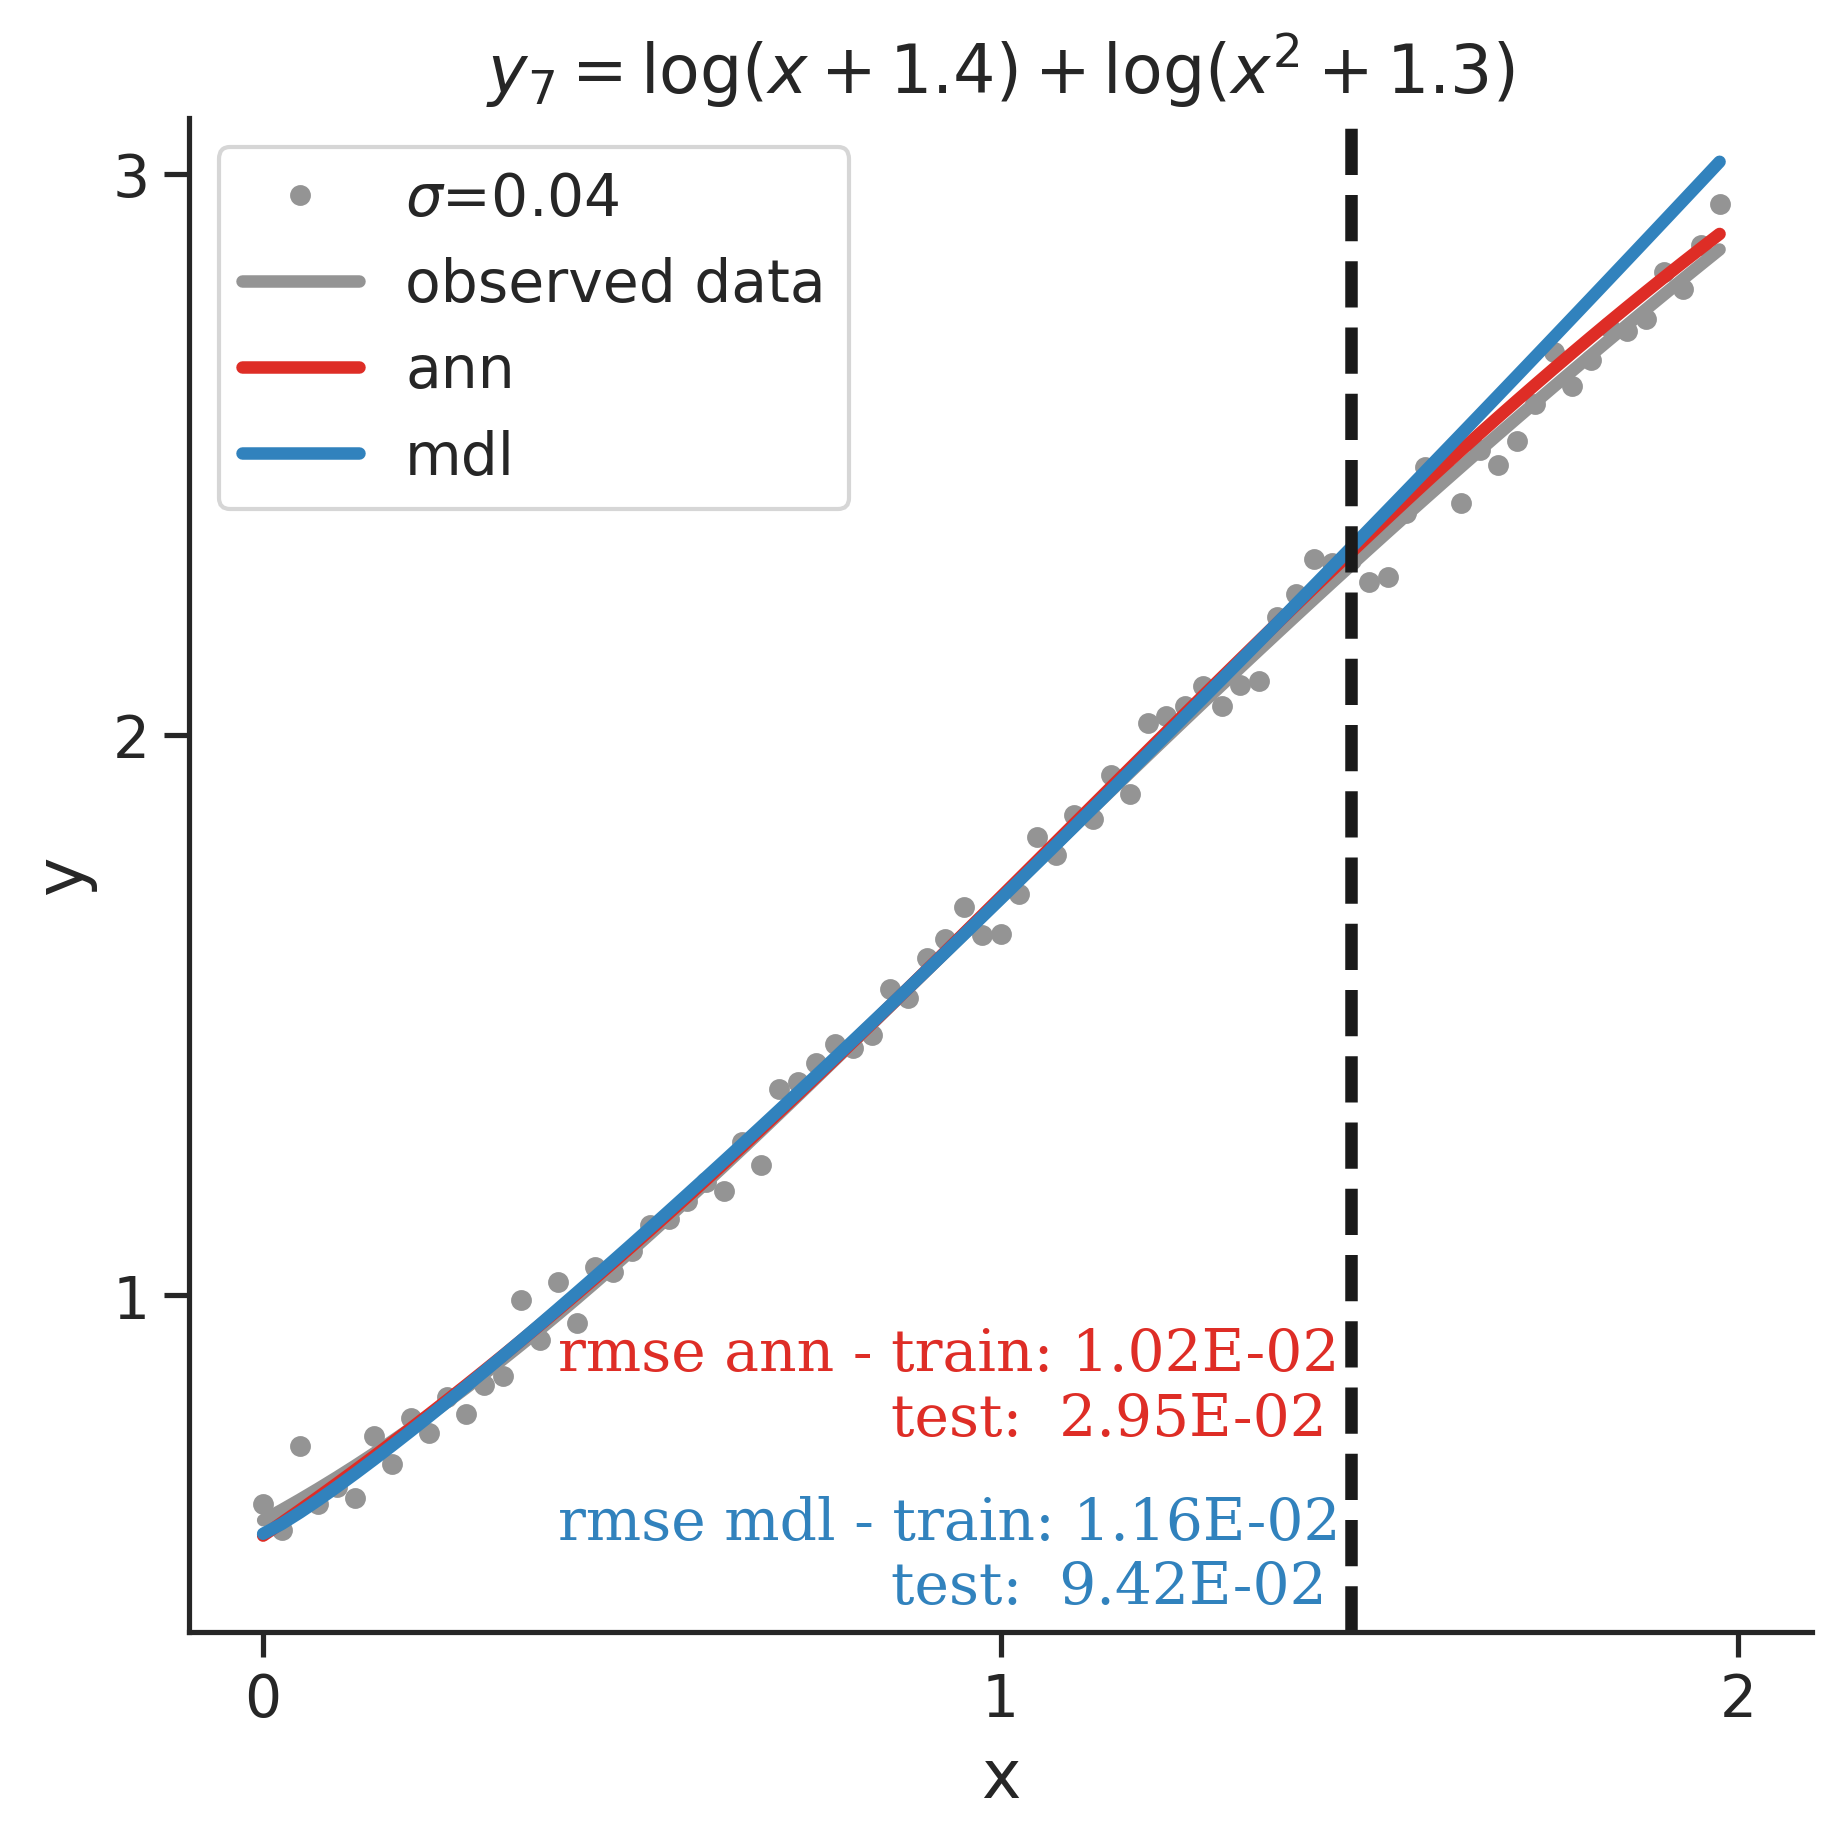

In [5]:
#Plot ann+bms predictions
dplot = deepcopy(dng1)
dplot['zbms'] = t1.predict(x1)

if dplot.zbms.isnull().values.any():
    print("there are Nans in the bms prediction")

#get errors
rmse_nn_train, rmse_nn_test, rmse_mdl_train, rmse_mdl_test, train_border=compute_errors_single_plot(dplot)


#Plot figure
fig=figure(figsize=(width,height), dpi=300)  

if n==10:
    ax = plt.figure().add_subplot(projection='3d')

    ax.plot(dng1.x, dng1.y, dng1.z_noise,'.', markersize=marker_s,linewidth=line_w,color=colors_figures['noise'],\
            label=r'$\sigma$=%s' %str(sigma))
    ax.plot(dng1.x, dng1.y, dng1.z, linewidth=line_w, color=colors_figures['data'],label='observed data')
    ax.plot(dng1['x'], dng1['y'], dng1['zmodel'],linewidth=line_w, color=colors_figures['ann'], label='ann')
    ax.plot(dplot.x, dplot.y, dplot.zbms, linewidth=line_w,color=colors_figures['bms'],label='mdl')
    
    ax.set_xticks(ticks[n]['x']);ax.set_yticks(ticks[n]['y']);ax.set_zticks(ticks[n]['z'])
    ax.set_xlabel('x',fontsize=text_size['axis']);ax.set_ylabel('y',fontsize=text_size['axis']);ax.set_zlabel('z',fontsize=text_size['axis'])
    ax.zaxis.labelpad=0.0 #Ensures the z label will show up

    #type errors on figure
    ax.text(coordinates_text[n][0], coordinates_text[n][1],coordinates_text[n][2],\
            'rmse ann - train: %.2E \n                  test:  %.2E' %( rmse_nn_train, rmse_nn_test),\
            color=color_ann,fontsize=size_legend,fontname='serif')
    ax.text(coordinates_text[n][0], coordinates_text[n][1],coordinates_text[n][2] -coordinates_text[n][3],\
            'rmse mdl - train: %.2E \n                  test:  %.2E' %(rmse_mdl_train, rmse_mdl_test),\
            color=color_bms,fontsize=size_legend,fontname='serif')
    plt.legend(loc='best', fontsize=size_legend)
    
else:
    plt.plot(dng1['x'], dng1['z_noise'],'.', markersize=marker_s, color=colors_figures['noise'],label=r'$\sigma$='+str(sigma)) 
    plt.plot(dng1['x'], dng1['z'], linewidth=line_w, color=colors_figures['data'],label='observed data') 
    plt.plot(dng1['x'], dng1['zmodel'],linewidth=line_w, color=colors_figures['ann'], label='ann')
    plt.plot(dplot.x, dplot.zbms, linewidth=line_w,color=colors_figures['bms'],label='mdl' )
    
    
    
    plt.xlabel('x',fontsize=text_size['axis']);plt.ylabel('y',fontsize=text_size['axis'])
    plt.xticks(ticks[n]['x'], fontsize=text_size['ticks']);plt.yticks(ticks[n]['y'], fontsize=text_size['ticks'])
    plt.xlim(limits[n]['x'][0], limits[n]['x'][1]);plt.ylim(limits[n]['y'][0], limits[n]['y'][1])

    plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')
    
    #type
    plt.text(coordinates_text[n][0], coordinates_text[n][1], \
             'rmse ann - train: %.2E \n                  test:  %.2E' % ( rmse_nn_train,rmse_nn_test), \
             color=colors_figures['ann'],fontsize=size_legend,fontname='serif')
    plt.text(coordinates_text[n][0], coordinates_text[n][1]-coordinates_text[n][2],\
             'rmse mdl - train: %.2E \n                  test:  %.2E' % (rmse_mdl_train,rmse_mdl_test), \
             color=colors_figures['bms'],fontsize=size_legend,fontname='serif')
    plt.legend(loc=loc_legend[n], fontsize=size_legend)


#Title: original function or bms-generated function
#---------------------------------------------------
plt.title(titles[n], fontsize=text_size['title'])
#plt.title('$y_{r%s}=%s$' %  (realization, t1.latex()), fontsize=size_title)
#---------------------------------------------------

#set limits and layout
sns.despine();plt.tight_layout()

#Save figure
namefig='%s_nguyen_noise_predictions_sigma_%s_r_%s_par_%s' % (str(n), str(sigma), str(realization), str(NPAR)   )

plt.savefig(output_path + namefig +'.svg',dpi=300)

display(t1,t1.par_values)

In [6]:
# Approximations
#--------------------------------------------------------------------------------------------------------------
errors_approximation=pd.read_csv('../data/'+ 'all_errors_nguyen' + '.csv',index_col=0)
#only take rmse results
columns=["sigma", "function","rmse_nn_train", "rmse_nn_test", "rmse_mdl_train", "rmse_mdl_test","r"]
errors_approximation=errors_approximation[columns]
#Melt dataframes and divide train and test
errors_train=errors_approximation[["sigma", "function","rmse_nn_train", "rmse_mdl_train","r"]]
errors_train=errors_train.rename(columns={"rmse_nn_train": "rmse ann", "rmse_mdl_train": "rmse mdl"})#change name columns for legends
errors_train=pd.melt(errors_train,id_vars=["sigma","function","r"], var_name="error approx",value_name= "value approx")

display(errors_train)

#Errors test. Not used, in principle
errors_test=errors_approximation[["sigma", "function","rmse_nn_test", "rmse_mdl_test","r"]]
errors_test=pd.melt(errors_test,id_vars=["sigma","function", "r"], var_name="error_test", value_name= "value_test")
#--------------------------------------------------------------------------------------------------------------

#Inter-extrapolation errors
#--------------------------------------------------------------------------------------------------------------
errors_inter_extra=pd.read_csv('../data/'+ 'all_errors_nguyen_interpolation' + '.csv',index_col=0)
#only take rmse results
columns=["sigma", "function","rmse_nn_interp.", "rmse_nn_extrap.", "rmse_mdl_interp.", "rmse_mdl_extrap.","r"]

#interpolation
errors_inter=errors_inter_extra[["sigma", "function","rmse_nn_interp.", "rmse_mdl_interp.","r"]]
errors_inter=errors_inter.rename(columns={"rmse_nn_interp.": "rmse ann", "rmse_mdl_interp.": "rmse mdl"})#change column names for legends
errors_inter=pd.melt(errors_inter,id_vars=["sigma","function","r"], var_name="error interp",value_name= "value interp")
#errors_inter=pd.melt(errors_inter,id_vars=["sigma","function","r"], var_name="error",value_name= "value")

#extrapolation
errors_extra=errors_inter_extra[["sigma", "function","rmse_nn_extrap.", "rmse_mdl_extrap.","r"]]
errors_extra=errors_extra.rename(columns={"rmse_nn_extrap.": "rmse ann", "rmse_mdl_extrap.": "rmse mdl"})#change column names for legends
errors_extra=pd.melt(errors_extra,id_vars=["sigma","function", "r"], var_name="error extrap", value_name= "value extrap")
#--------------------------------------------------------------------------------------------------------------
display(errors_extra)

,sigma,function,r,error approx,value approx
0,0.00,1,0,rmse ann,0.004630
1,0.00,1,1,rmse ann,0.004722
2,0.00,1,2,rmse ann,0.003089
3,0.02,1,0,rmse ann,0.013321
4,0.02,1,1,rmse ann,0.005137
...,...,...,...,...,...
325,0.18,10,1,rmse mdl,0.008894
326,0.18,10,2,rmse mdl,0.007170
327,0.20,10,0,rmse mdl,0.006781
328,0.20,10,1,rmse mdl,0.006569


,sigma,function,r,error extrap,value extrap
0,0.00,1,0,rmse ann,1.167822
1,0.00,1,1,rmse ann,1.342675
2,0.00,1,2,rmse ann,1.172886
3,0.02,1,0,rmse ann,1.052788
4,0.02,1,1,rmse ann,0.984614
...,...,...,...,...,...
325,0.18,10,1,rmse mdl,0.030373
326,0.18,10,2,rmse mdl,0.020128
327,0.20,10,0,rmse mdl,0.025360
328,0.20,10,1,rmse mdl,0.028522


In [7]:
#Select function to plot
errors_train_plot=errors_train[errors_train['function']==n]
errors_inter_plot=errors_inter[errors_inter['function']==n]
errors_extra_plot=errors_extra[errors_extra['function']==n]

6.299212598425196 6.299212598425196


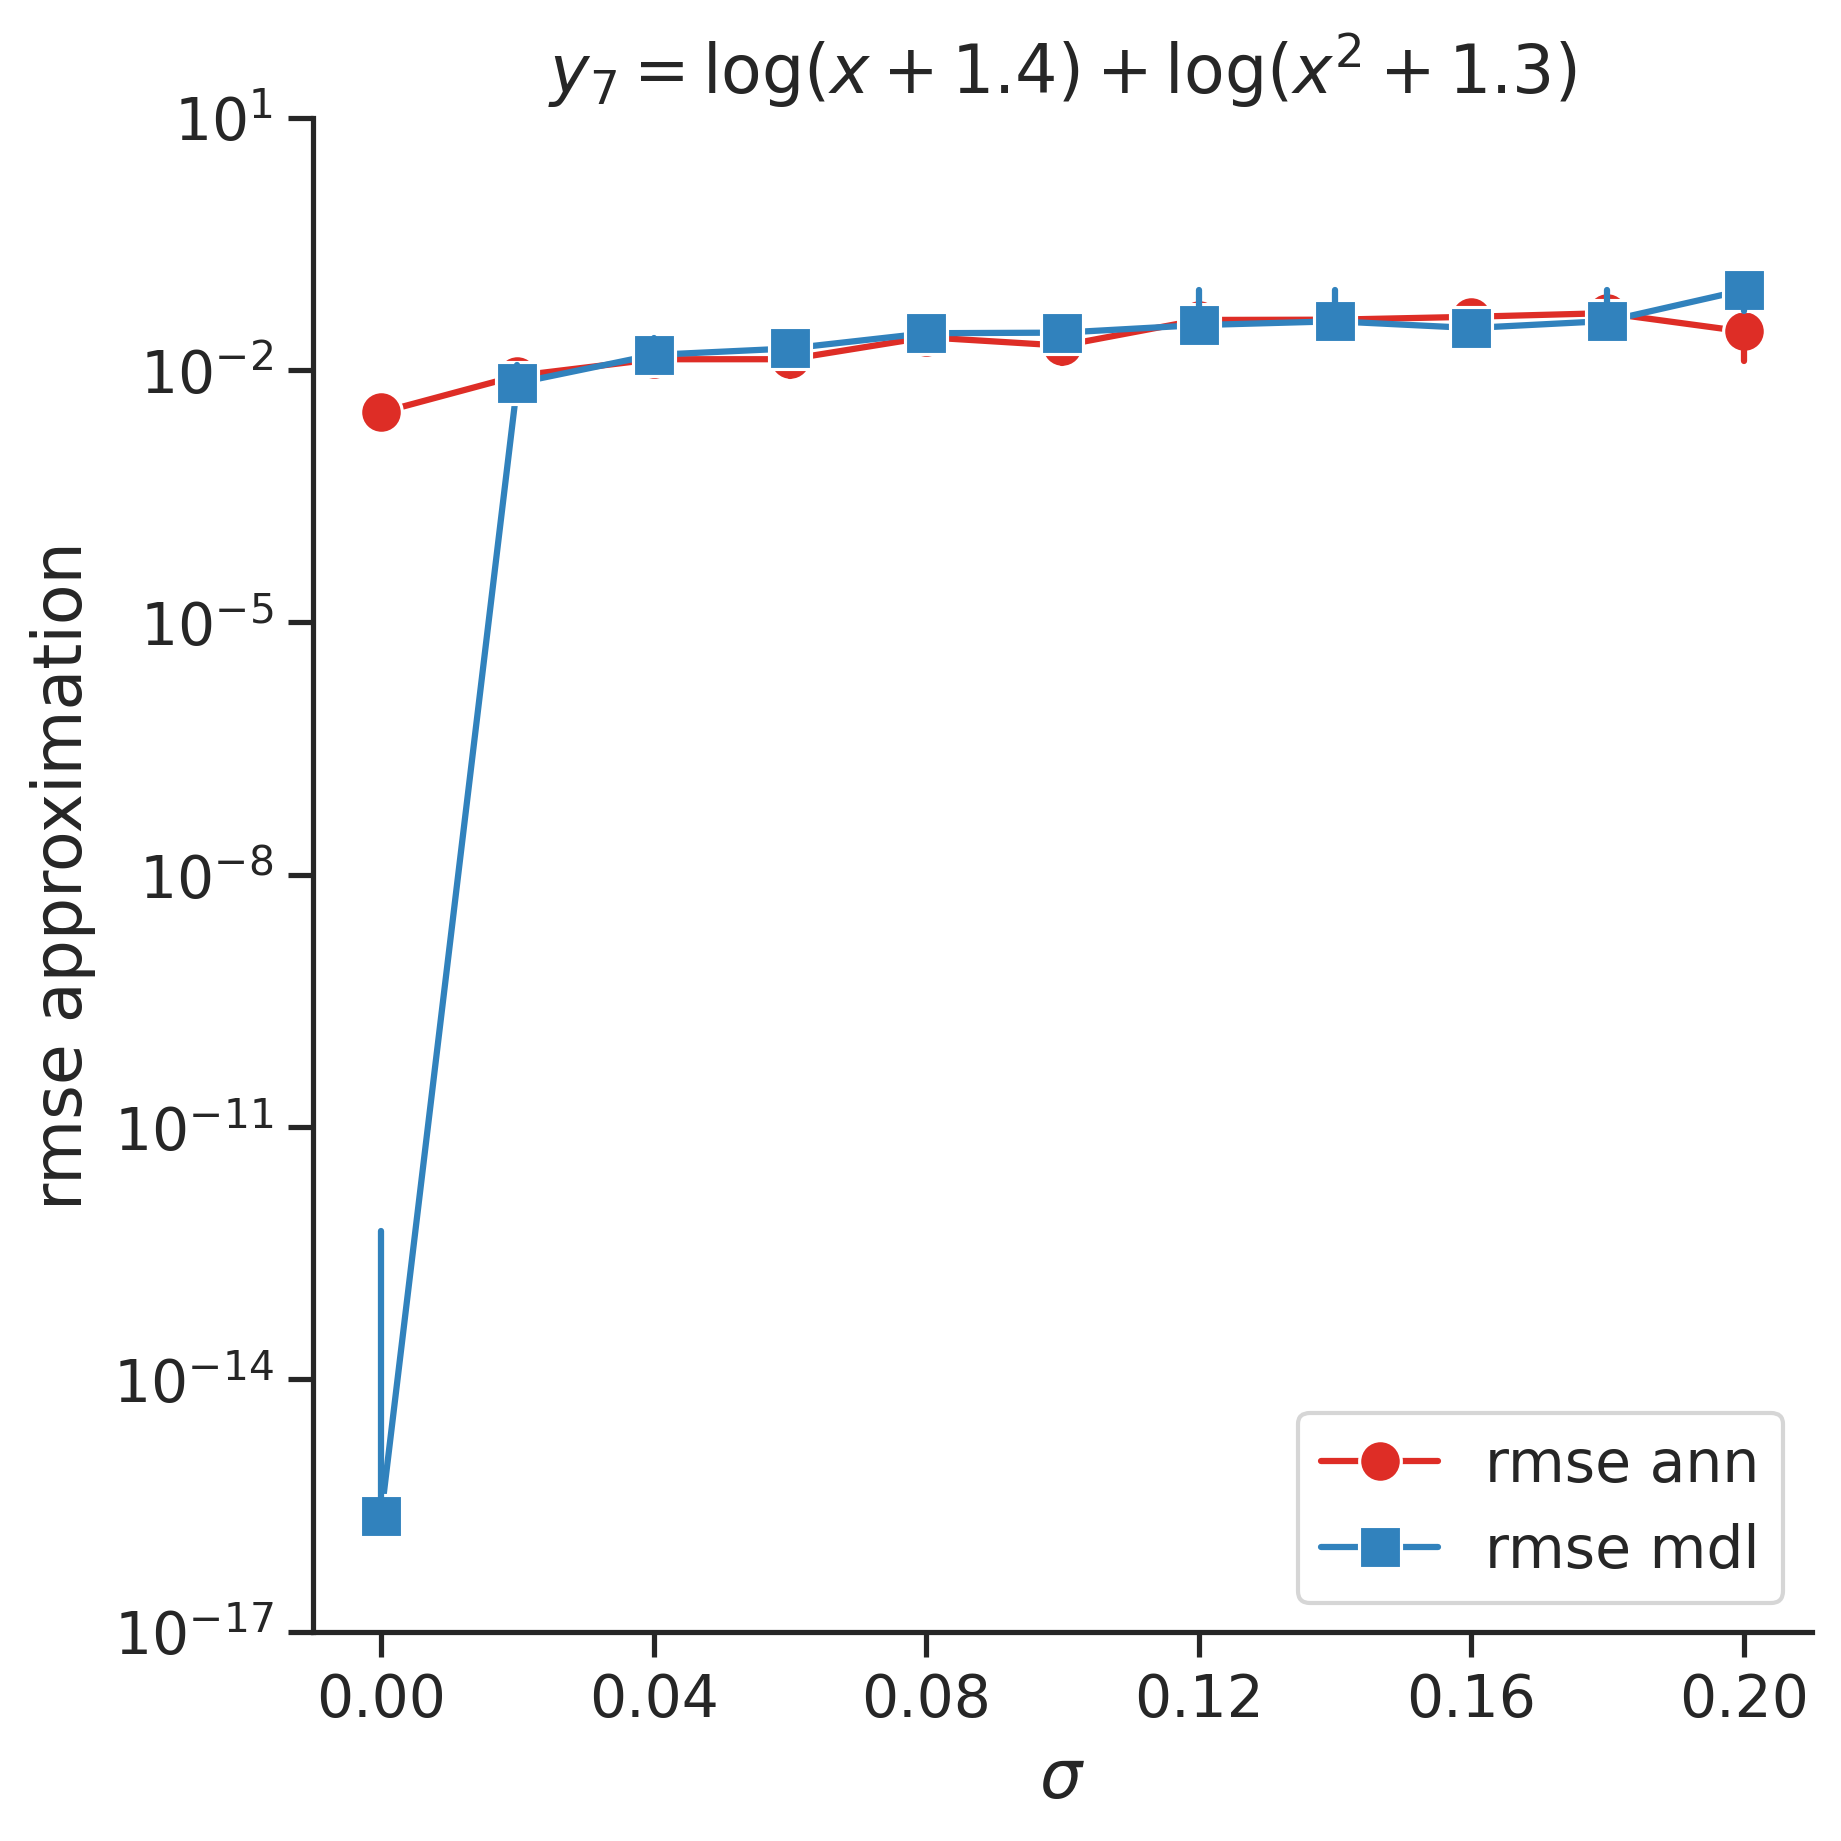

In [8]:
#approximation
#-------------------------------------------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300)
print(width, height)

sns.lineplot(
        data=errors_train_plot, x='sigma', y='value approx', hue='error approx', style='error approx',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_train'], markers['rmse_mdl_train']], dashes=False, markersize=m_size, legend="full", 
        palette=[colors_figures['1x'][0], colors_figures['1x'][1]])

#labels, limits, and ticks
plt.title(titles[n],fontsize=text_size['title'])
plt.xlabel(r'$\sigma$',fontsize=text_size['axis']);plt.ylabel('rmse approximation',fontsize=text_size['axis'])
plt.yscale("log")
#plt.xticks(fontsize=text_size['ticks']);plt.yticks(fontsize=text_size['ticks'])
xtick_labels=np.arange(0.0,0.22,0.04)
plt.xticks(xtick_labels, fontsize=text_size['ticks']);plt.yticks(fontsize=text_size['ticks'])
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

plt.legend(loc='lower right', fontsize=text_size['legend'])

namefig_app='approximation_' + str(n) 
plt.savefig(output_path+namefig_app + '.svg',dpi=300)
#-------------------------------------------------------------------------------------------------------------------

6.299212598425196 6.299212598425196


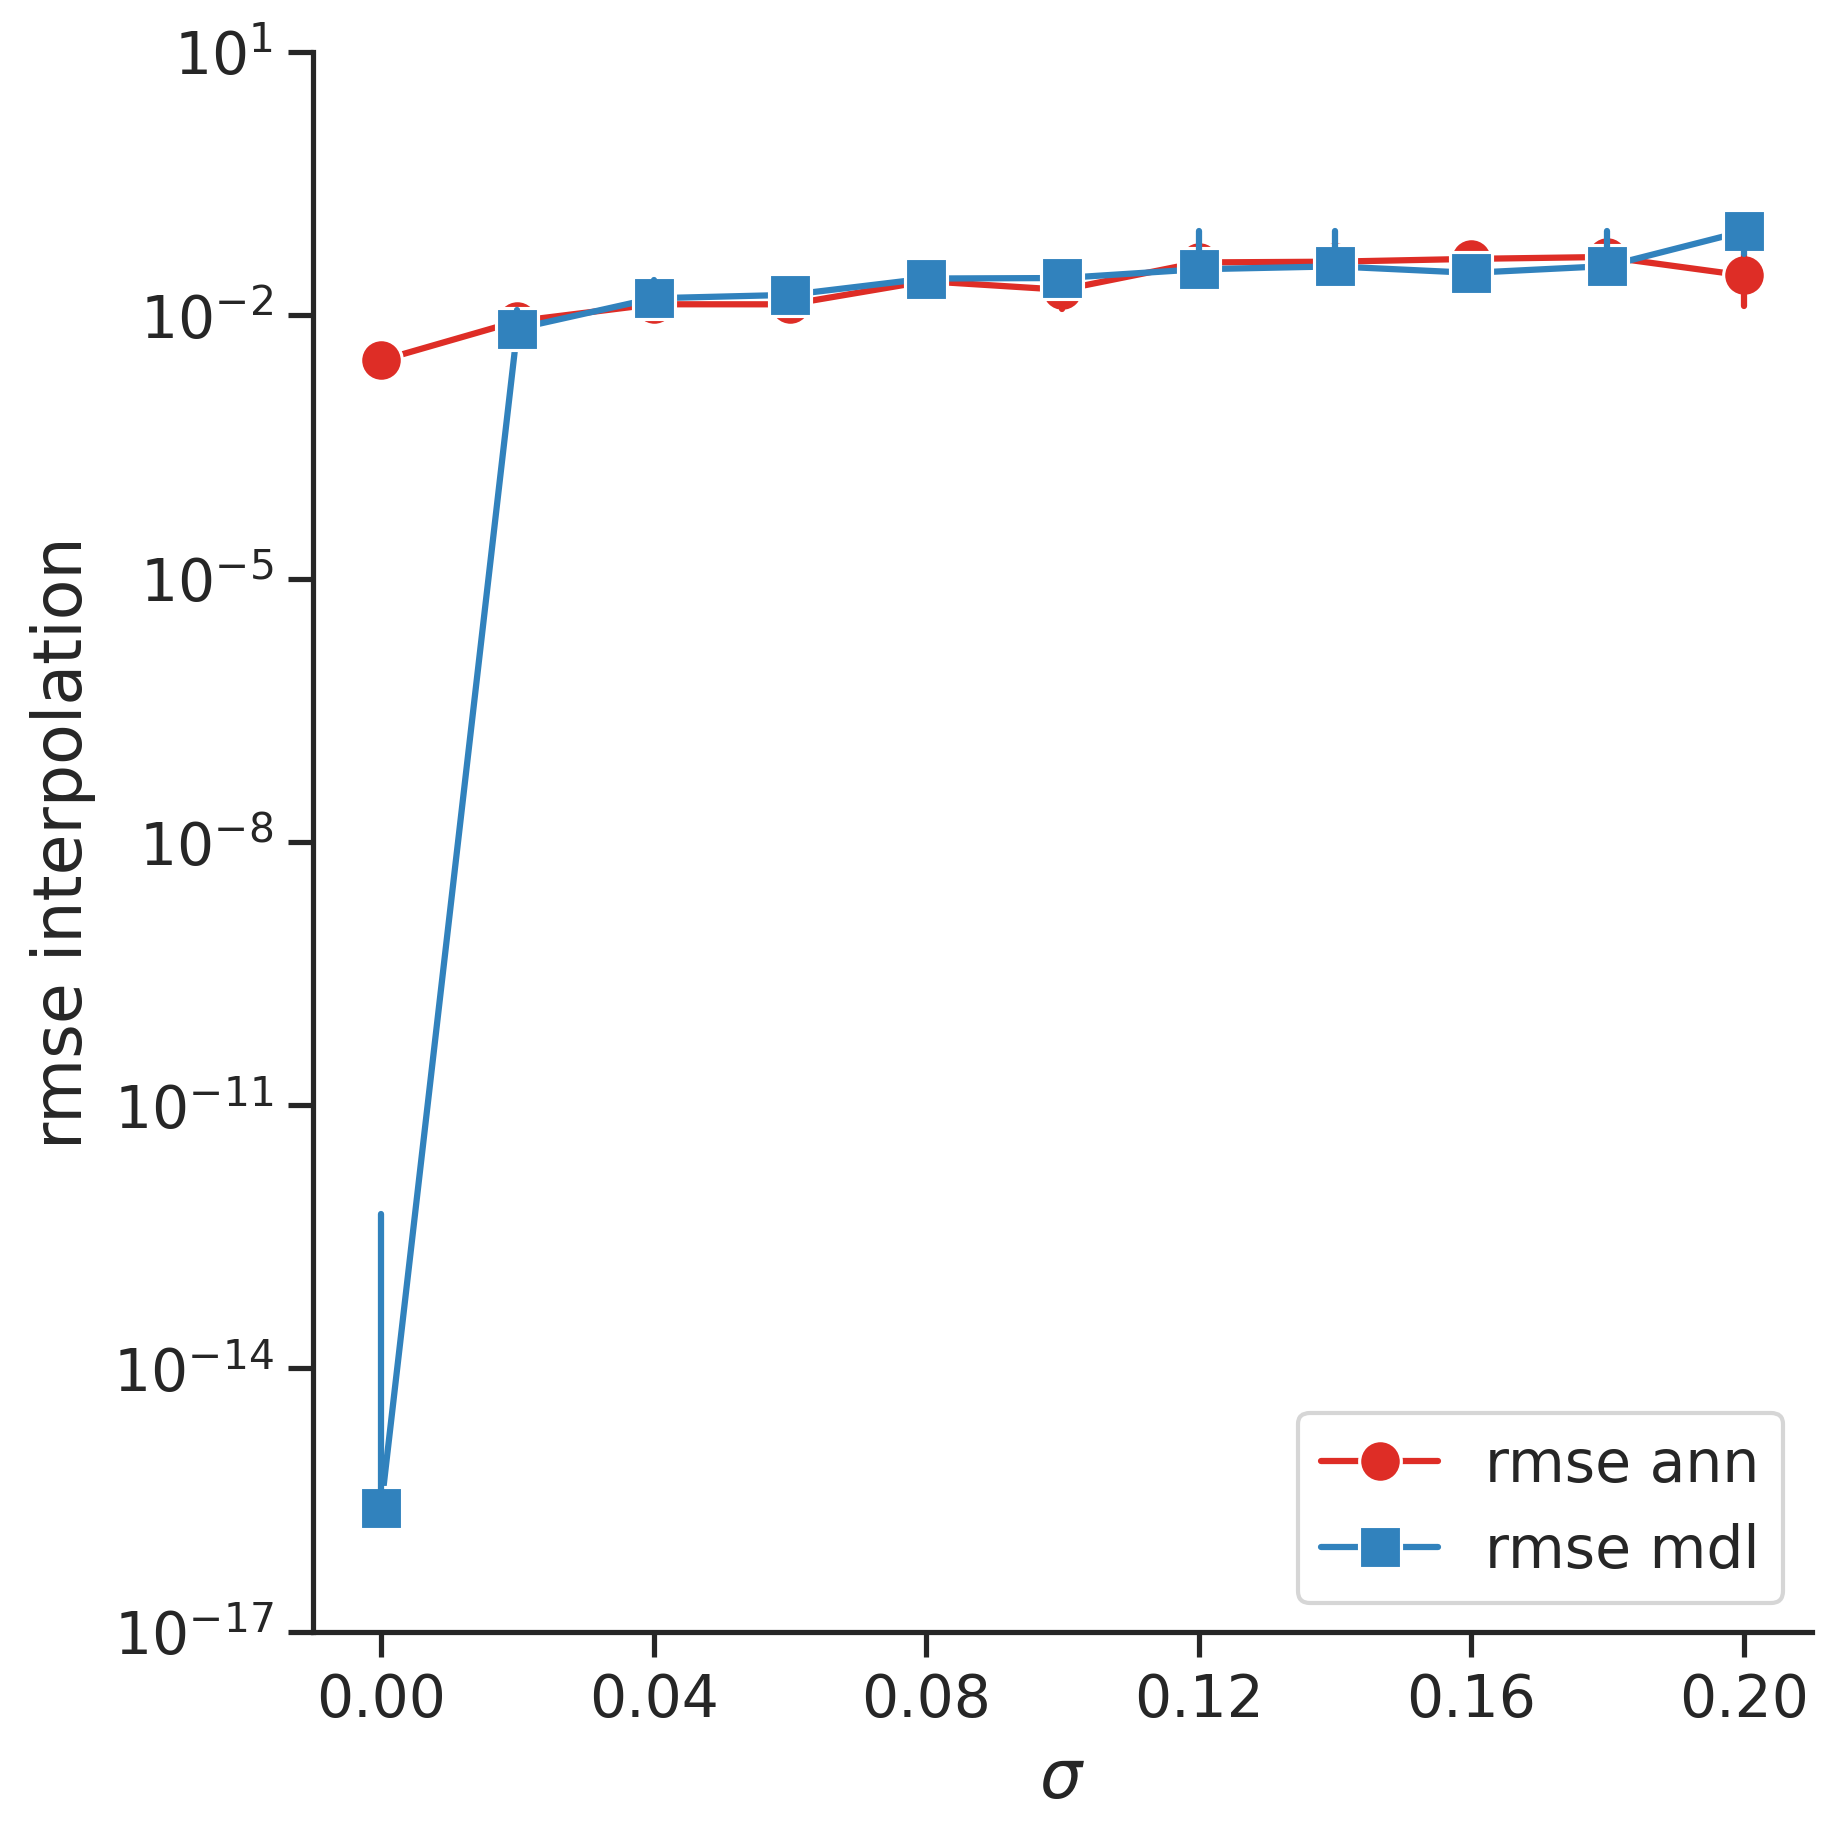

In [9]:
#interpolation
#-------------------------------------------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300)
print(width, height)

sns.lineplot(
        data=errors_inter_plot, x='sigma', y='value interp', hue='error interp', style='error interp',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_train'], markers['rmse_mdl_train']], dashes=False, markersize=m_size, legend=True, 
        palette=[colors_figures['1x'][0], colors_figures['1x'][1]])

#labels, limits, and ticks
#plt.title(titles[func_number],fontsize=size_ticks)
plt.xlabel(r'$\sigma$',fontsize=text_size['axis']);plt.ylabel('rmse interpolation',fontsize=text_size['axis'])
plt.yscale("log")

xtick_labels=np.arange(0.0,0.22,0.04)
plt.xticks(xtick_labels, fontsize=text_size['ticks']);plt.yticks(fontsize=text_size['ticks'])
plt.minorticks_off()
plt.ylim(ymin,ymax)

sns.despine();plt.tight_layout()

plt.legend(loc='lower right', fontsize=text_size['legend'])

namefig_inter='interpolation_' + str(n)
plt.savefig(output_path+namefig_inter + '.svg',dpi=300)
#-------------------------------------------------------------------------------------------------------------------

6.299212598425196 6.299212598425196


,sigma,function,r,error extrap,value extrap
66,0.00,7,0,rmse ann,0.018975
67,0.00,7,1,rmse ann,0.043898
68,0.00,7,2,rmse ann,0.053996
69,0.02,7,0,rmse ann,0.107071
70,0.02,7,1,rmse ann,0.079782
...,...,...,...,...,...
259,0.18,7,1,rmse mdl,0.052264
260,0.18,7,2,rmse mdl,0.211375
261,0.20,7,0,rmse mdl,0.243157
262,0.20,7,1,rmse mdl,0.099657


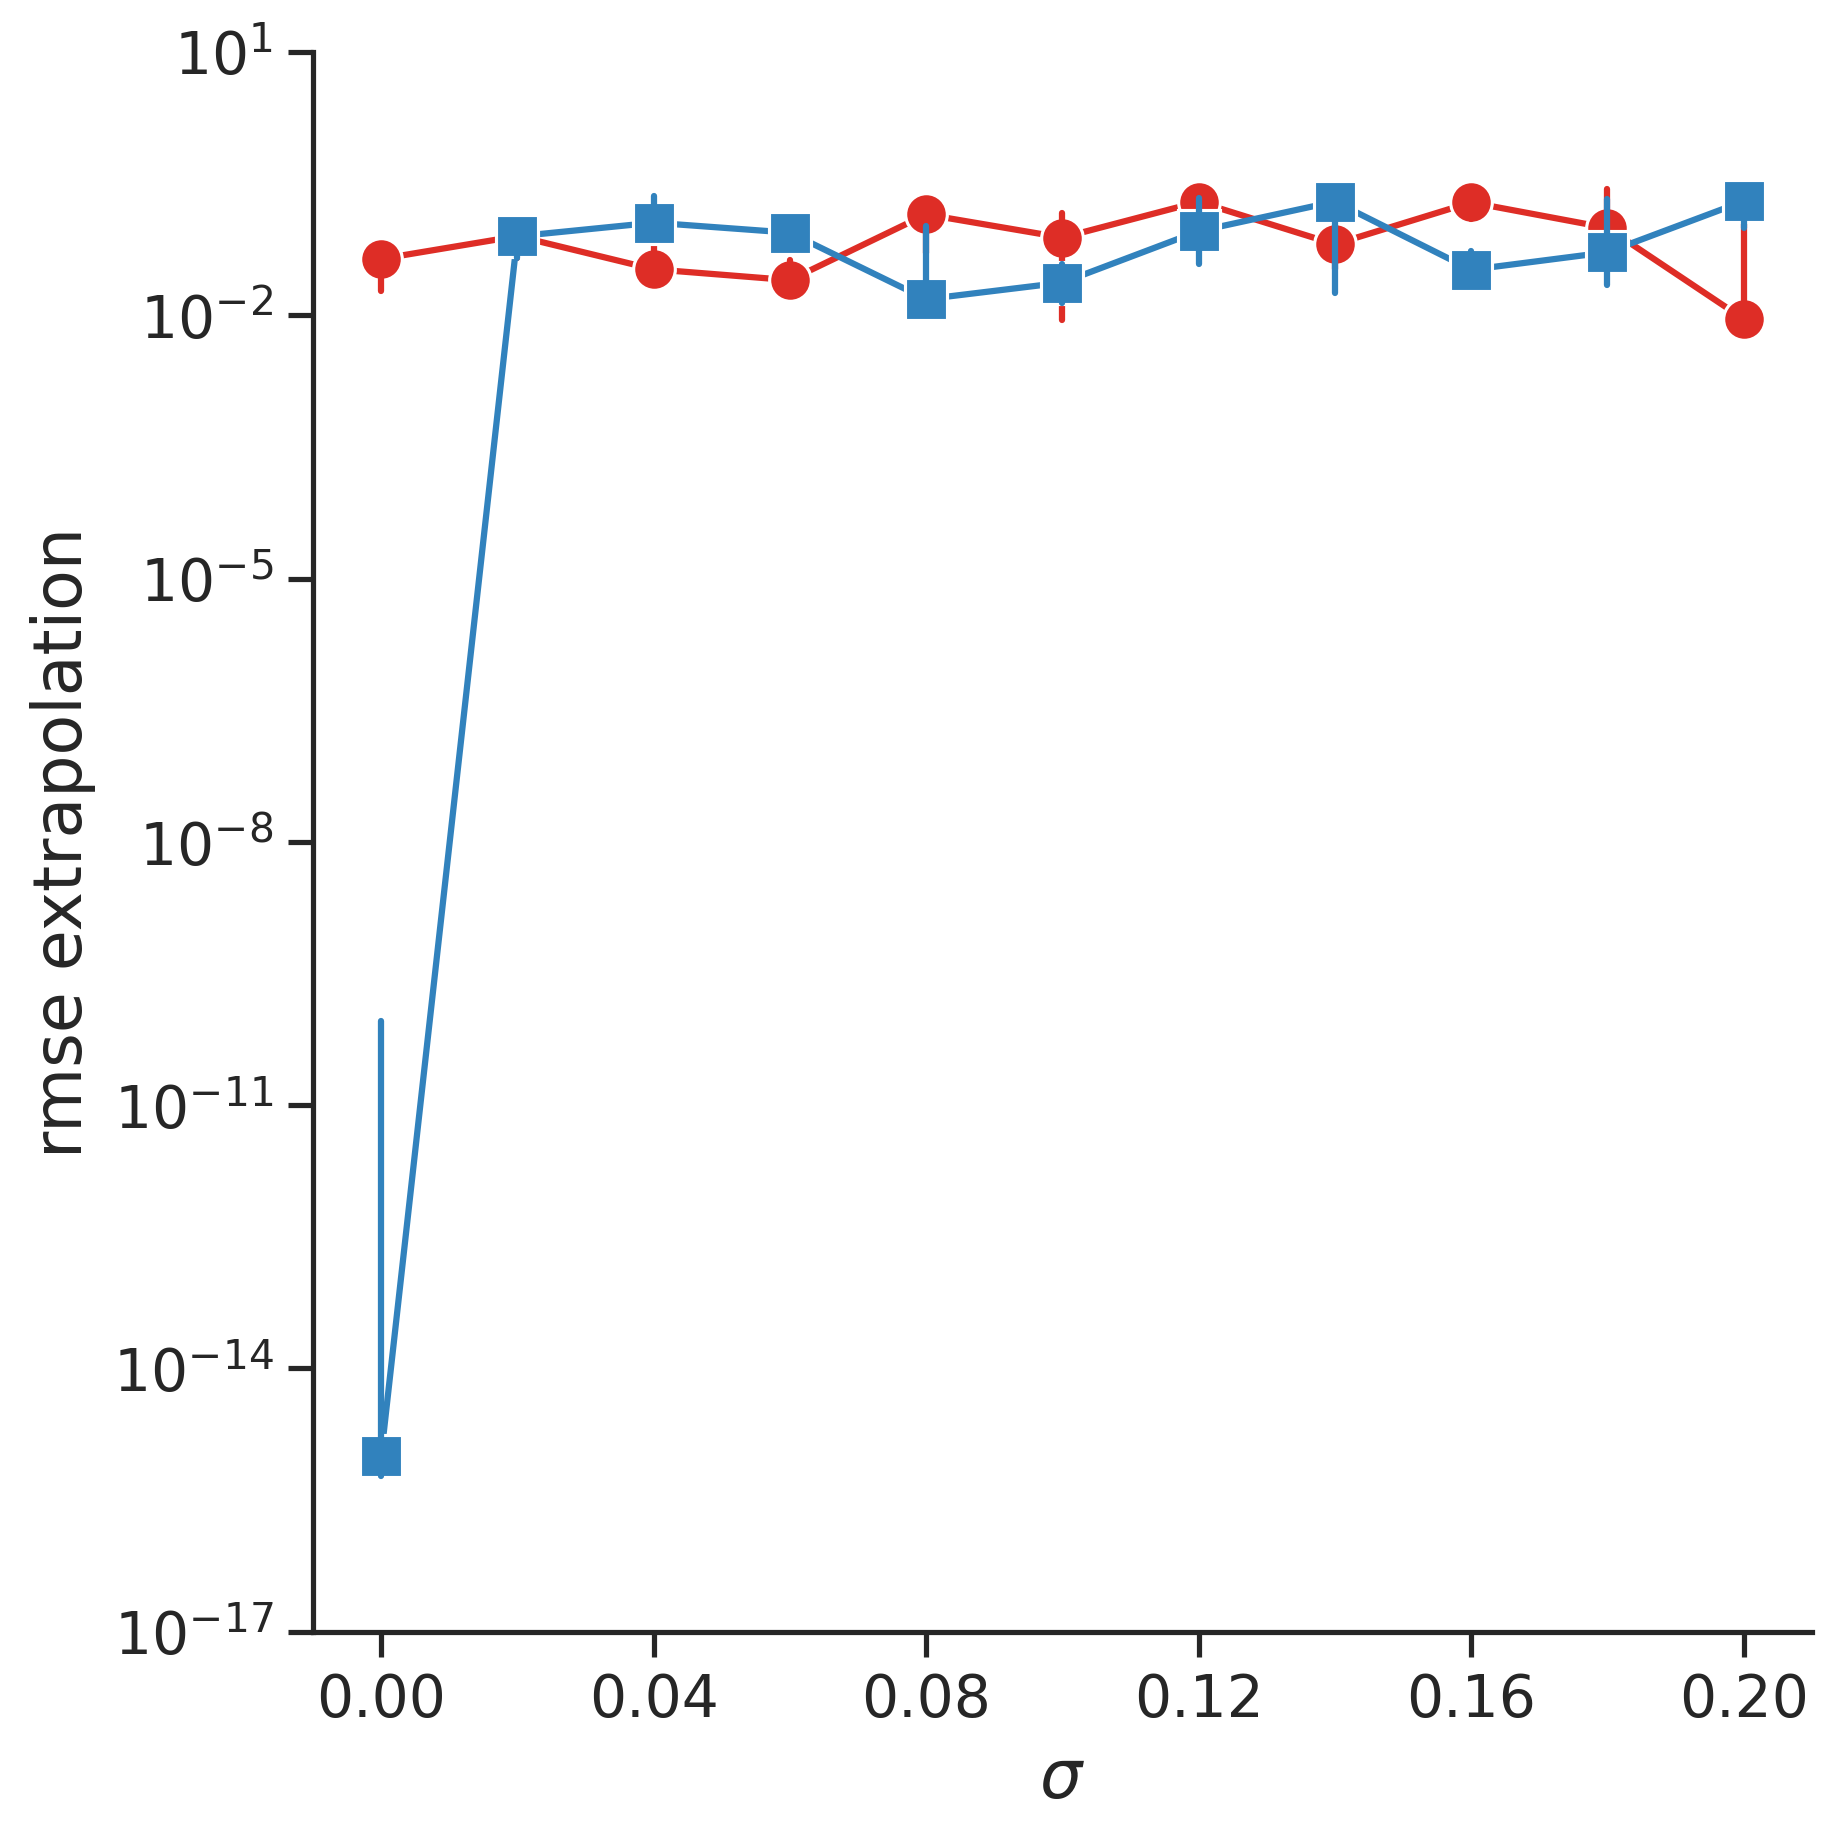

In [10]:
#Extrapolation
#-------------------------------------------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300)
print(width, height)

display(errors_extra_plot)

sns.lineplot(
        data=errors_extra_plot, x='sigma', y='value extrap', hue='error extrap', style='error extrap',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_train'], markers['rmse_mdl_train']], dashes=False, markersize=m_size, legend=False, 
        palette=[colors_figures['1x'][0], colors_figures['1x'][1]])

#labels, limits, and ticks
#plt.title(titles[func_number],fontsize=size_ticks)
plt.xlabel(r'$\sigma$',fontsize=text_size['axis']);plt.ylabel('rmse extrapolation',fontsize=text_size['axis'])
plt.yscale("log")

xtick_labels=np.arange(0.0,0.22,0.04)
plt.xticks(xtick_labels, fontsize=text_size['ticks']);plt.yticks(fontsize=text_size['ticks'])
plt.minorticks_off()
plt.ylim(ymin,ymax)

sns.despine();plt.tight_layout()

namefig_extrap='extrapolation_' + str(n)
plt.savefig(output_path+namefig_extrap+ '.svg',dpi=300)
#-------------------------------------------------------------------------------------------------------------------